## 1. Data Ingestion & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
df=pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2.Data Cleaning & Feature Engineering

In [3]:
print(df.isnull().sum())
current_year = datetime.datetime.now().year
df['Car_Age']=current_year-df['Year']
df.drop(['Car_Name','Year'],axis=1,inplace=True)
df=pd.get_dummies(df,drop_first=True)
df.head()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


3. Model Training & Pipeline Implementation

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# Separate features (X) and target variable (y)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Make predictions and evaluate performance
predictions = model.predict(X_test)
print("R2 Score:", metrics.r2_score(y_test, predictions))
print("MAE:", metrics.mean_absolute_error(y_test, predictions))

R2 Score: 0.9606688792821501
MAE: 0.6325622950819674


4. Model Performance & Residual Analysis

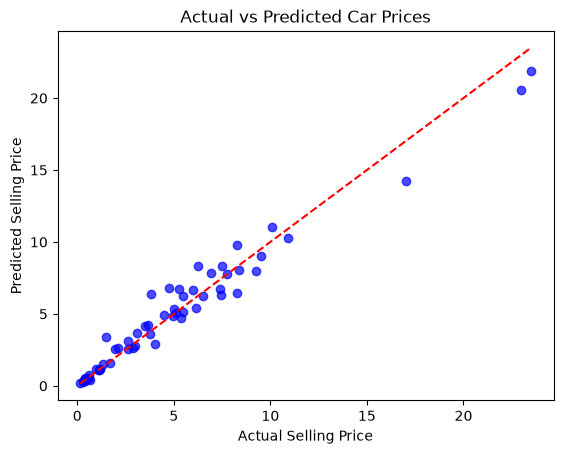

In [5]:
plt.scatter(y_test, predictions, alpha=0.7, color='blue')
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

5. Single Sample Inference & Model Verification

In [6]:
# Predict for a single test sample
sample_car = X_test.iloc[0:1]
actual_price = y_test.iloc[0]
predicted_price = model.predict(sample_car)[0]

print(f"Actual Price: {actual_price:.2f} Lakhs")
print(f"Predicted Price: {predicted_price:.2f} Lakhs")

Actual Price: 0.35 Lakhs
Predicted Price: 0.44 Lakhs


6. Data Ingestion & Library Impoerts,Environments Setup

In [1]:
import datetime
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

import gradio as gr

# Load dataset
df = pd.read_csv('car data.csv')
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


7. Dataset Partitioning & Feature Selection

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8.Data Loading & Preprocessing Pipeline

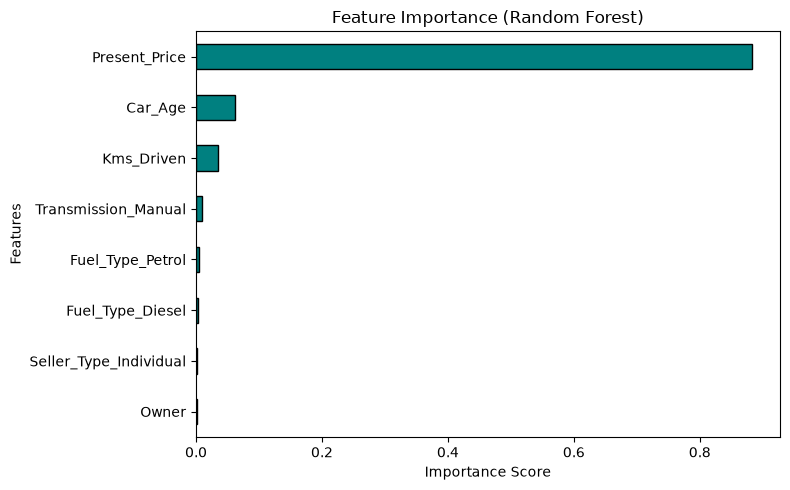

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. Load data
df = pd.read_csv('car data.csv')

# 2. Feature engineering & cleaning
df['Car_Age'] = 2026 - df['Year']
df.drop(['Car_Name', 'Year'], axis=1, errors='ignore', inplace=True)

# 3. One-hot encode categorical features
df = pd.get_dummies(df, drop_first=True)

# 4. Separate X and y
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Fit Random Forest Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# 7. Plot Feature Importance
plt.figure(figsize=(8, 5))
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='teal', edgecolor='black')

plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [11]:
model=RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

9. Initial Exploratory Data Analysis

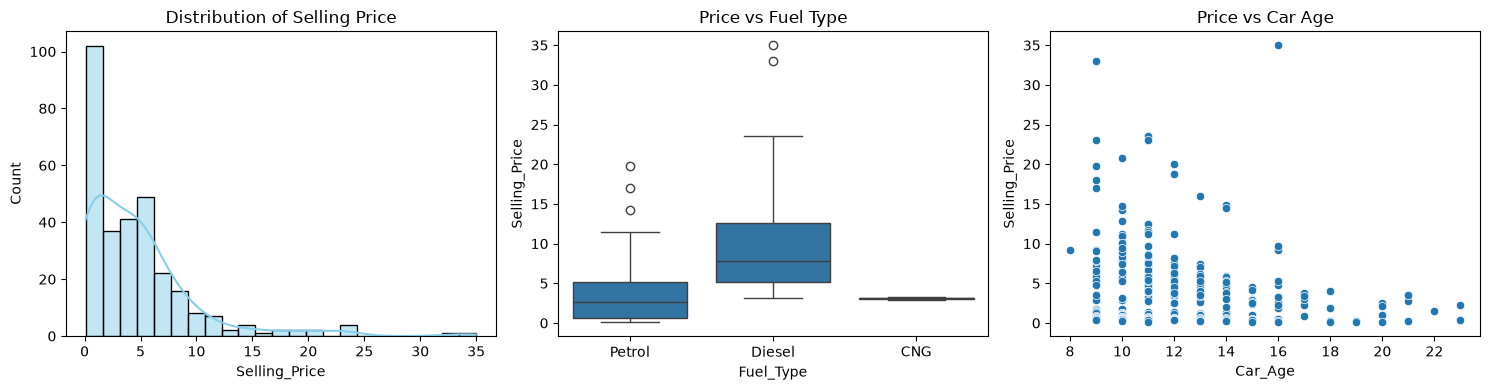

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 4))

# Distribution of selling prices
plt.subplot(1, 3, 1)
sns.histplot(df['Selling_Price'], kde=True, color='skyblue')
plt.title('Distribution of Selling Price')

# Boxplot: Selling Price vs Fuel Type
plt.subplot(1, 3, 2)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=pd.read_csv('car data.csv'))
plt.title('Price vs Fuel Type')

# Scatterplot: Selling Price vs Car Age
plt.subplot(1, 3, 3)
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)
plt.title('Price vs Car Age')

plt.tight_layout()
plt.show()

10. Feature Correlation Heatmap

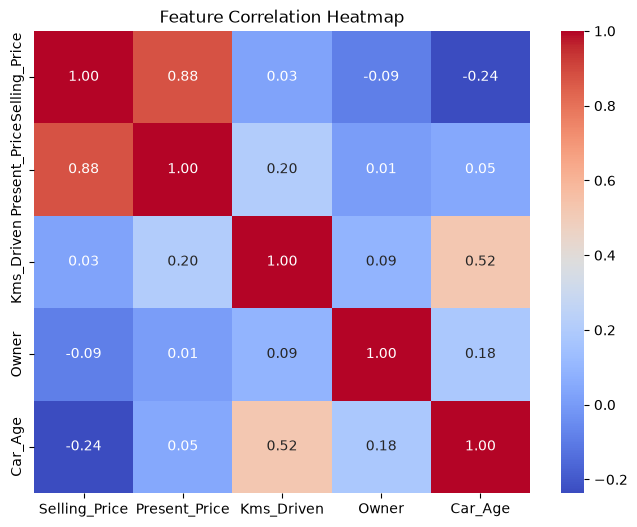

In [14]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

11. Linear Regression

In [16]:
import numpy as np
from sklearn import metrics
from sklearn.linear_model import LinearRegression

# 1. Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Model Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = model.predict(X_test)

# 3. Compare Evaluation Metrics (R2, MAE, RMSE)
print("=== Model Comparison ===")
print(
    f"Random Forest     -> R2: {metrics.r2_score(y_test, rf_preds):.4f} |"
    f" MAE: {metrics.mean_absolute_error(y_test, rf_preds):.4f} | RMSE:"
    f" {np.sqrt(metrics.mean_squared_error(y_test, rf_preds)):.4f}"
)
print(
    f"Linear Regression -> R2: {metrics.r2_score(y_test, lr_preds):.4f} |"
    f" MAE: {metrics.mean_absolute_error(y_test, lr_preds):.4f} | RMSE:"
    f" {np.sqrt(metrics.mean_squared_error(y_test, lr_preds)):.4f}"
)

=== Model Comparison ===
Random Forest     -> R2: 0.9575 | MAE: 0.6575 | RMSE: 0.9892
Linear Regression -> R2: 0.8490 | MAE: 1.2162 | RMSE: 1.8652
